# 5 Modeling<a id='5_Modeling'></a>

## 5.1 Contents<a id='4.1_Contents'></a>
* [5 Modeling](#5_Modeling)
  * [5.1 Contents](#5.1_Contents)
  * [5.2 Introduction](#4.2_Introduction)
  * [5.3 Imports](#4.3_Imports)
  * [5.4 Load Data](#4.4_Load_Data)
  * [5.5 Linear Regression Models](#5.5_Linear_Regression_Models)
  * [5.6 Random Forest Model](#5.6_Random_Forest_Model)
  * [5.7 Test Models for Second Feature Set (Population Signal Removed)](#5.7_All_Models)
  * [5.8 Final Models Selection](#4.11_Final_Model_Selection)
  * [5.9 Save best model object from pipeline](#5.10_Save_best_model_object_from_pipeline)
  * [5.10 The Plastics Connection](#5.9_The_Plastics_Connection)
  * [5.11 Conclusion](#5.10_Conclusion)
  * [5.12 Actionable Isights](#5.12_Actionable_Insights)
  * [5.13 Summary](#5.11_Summary)

## 5.2. Introduction<a id='5.2_Introduction'></a>

In the previous notebook, we did PCA analysis and finalized our feature set by keeping the original log features created during EDA. Then, we created train/test sets for 2 different feature/target variable sets (total co2 and co2_per_capita as targets). We also standardized our numerical features data.

In this notebook we will build different machine learning models and determine the best model and strategy for deriving actionable insights on the impact of national economic activity, energy usage and demographic indicators over the past many decades on global warming using carbon dioxide emission levels as our key indicator. We will further tie this to plastics production as a macro driver for carbon dioxide emissions and hence global warming.

##  5.3 Imports<a id='5.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime
from library.sb_utils import save_file

## 5.4 Load Data<a id='5.4_Load_Data'></a>

In [77]:
#Data for modeling
co2_data = pd.read_csv('../data/processed/model_ready_data.csv')
co2_data.head()

#Data for establishing Plastics connection later on in the notebook
global_co2_plastics_data = pd.read_csv('../data/processed/co2_plastics_global_data_cleaned.csv')
global_co2_plastics_norm = pd.read_csv('../data/processed/global_co2_plastics_norm.csv')

In [3]:
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4853 non-null   object 
 1   year                   4853 non-null   int64  
 2   iso_code               4853 non-null   object 
 3   log_co2                4853 non-null   float64
 4   log_gdp_per_capita     4853 non-null   float64
 5   log_energy_per_capita  4853 non-null   float64
 6   log_population         4853 non-null   float64
 7   log_co2_per_capita     4853 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 303.4+ KB


In [31]:
#First Strategy
train = pd.read_csv('../data/processed/train.csv')
test = pd.read_csv('../data/processed/test.csv')
train_scaled = pd.read_csv('../data/processed/train_scaled.csv')
test_scaled = pd.read_csv('../data/processed/test_scaled.csv')
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = np.ravel(pd.read_csv('../data/processed/y_train.csv'))
y_test = np.ravel(pd.read_csv('../data/processed/y_test.csv'))

#Second Strategy
train2 = pd.read_csv('../data/processed/train2.csv')
test2 = pd.read_csv('../data/processed/test2.csv')
train2_scaled = pd.read_csv('../data/processed/train2_scaled.csv')
test2_scaled = pd.read_csv('../data/processed/test2_scaled.csv')
X_train2 = pd.read_csv('../data/processed/X_train2.csv')
X_test2 = pd.read_csv('../data/processed/X_test2.csv')
y_train2 = np.ravel(pd.read_csv('../data/processed/y_train2.csv'))
y_test2 = np.ravel(pd.read_csv('../data/processed/y_test2.csv'))

In [35]:
#features and target variables' definitions
# first approach
target = 'log_co2'
num_features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
cat_features = ['country']
#second approach
target2 = 'log_co2_per_capita'
num_features2 = ['log_gdp_per_capita','log_energy_per_capita']
cat_features2 = ['country']

## 5.5 Linear Regression Models<a id='5.5_Linear_Regression_Models'></a>

##### 5.5.1 Ordinary Least Squares Model<a id='5.5.1_Ordinary_Least_Squares_Model'></a>

##### 5.5.1.1 Unscaled Model<a id='5.5.1.1_Unscaled_Model'></a>

In [36]:
#fixed effect unscaled ols model without cv
#fit the ols model
ols_model = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita + C(country)', data = train).fit()

In [37]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_co2   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     3537.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:30:38   Log-Likelihood:                 971.35
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3878   BIC:                            -572.4
Df Model:                         164                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [38]:
#predict the model
test['ols_pred'] = ols_model.predict(test)

In [39]:
#evaluate results
rmse = np.sqrt(mean_squared_error(test[target],test['ols_pred']))
print(rmse)

0.2625980595499516


##### 5.5.1.2 Scaled Model<a id='5.5.1.2_Scaled_Model'></a>

In [40]:
#fixed effect ols model without cv
#fit the ols model
ols_model_scaled = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita + C(country)', data = train_scaled).fit()

In [41]:
print(ols_model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                log_co2   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     3537.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:30:50   Log-Likelihood:                 971.35
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3878   BIC:                            -572.4
Df Model:                         164                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [42]:
#predict the model
test_scaled['ols_pred_scaled'] = ols_model_scaled.predict(test_scaled)

In [43]:
#evaluate results
rmse = np.sqrt(mean_squared_error(test_scaled[target],test_scaled['ols_pred_scaled']))
print(rmse)

0.2625980595499519


##### 5.5.2 Ridge Regression Model<a id='5.5.2_Ridge_Regression_Model'></a>

In [44]:
#preprocess columns using scaler and then onehotencoder for categorical features
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features),
    ]
)

#pipeline for ridge regression model
pipeline_ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
])

In [45]:
#crossvalidation and grid search
tscv = TimeSeriesSplit(n_splits=5)
param_grid_ridge = {'model__alpha': [0.1, 1, 10, 50, 100] }
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=tscv, scoring = 'neg_mean_squared_error', n_jobs=-1)

In [46]:
#Fit Ridge Model and get best params
grid_ridge.fit(X_train, y_train)
print(grid_ridge.best_params_)

{'model__alpha': 10}


In [47]:
ridge_pred = grid_ridge.predict(X_test)

In [48]:
#evaluate results
rmse = np.sqrt(mean_squared_error( y_test, ridge_pred))
print(rmse)

0.2311889197366216


([0, 1, 2],
 [Text(0, 0, 'num__log_population'),
  Text(1, 0, 'num__log_energy_per_capita'),
  Text(2, 0, 'num__log_gdp_per_capita')])

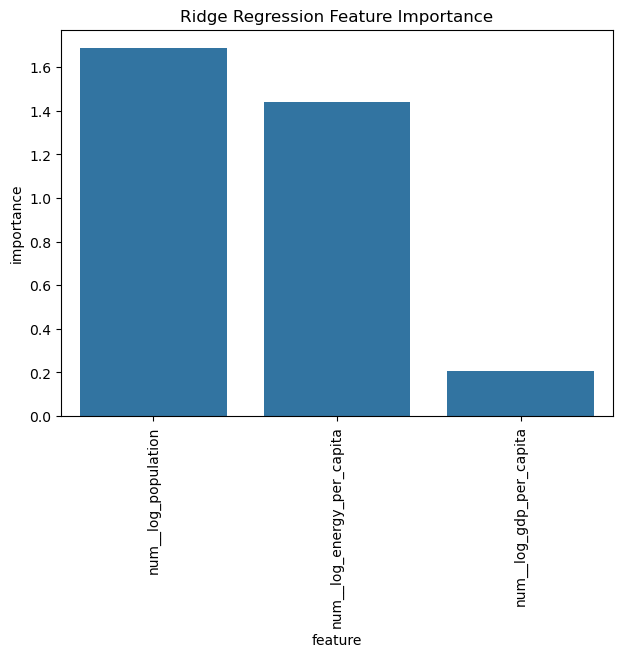

In [136]:
#assessing feature importance with ridge regression model
ridge_model = grid_ridge.best_estimator_
coef = ridge_model.named_steps['model'].coef_
features = ridge_model.named_steps['preprocessor'].get_feature_names_out()
ridge_feature_imp = pd.DataFrame({'feature': features, 'coefficient': coef, 'importance':np.abs(coef)}).sort_values(by='importance',ascending=False)
ridge_feature_imp_core = ridge_feature_imp[ridge_feature_imp['feature'].isin(['num__log_energy_per_capita','num__log_gdp_per_capita', 'num__log_population'])]
_=sns.barplot(ridge_feature_imp_core, x='feature', y='importance')
plt.title("Ridge Regression Feature Importance")
plt.tight_layout()
plt.xticks(rotation=90)

Ridge Regression model feature importance was evaluated using standardized coefficients. While countries as features were included in modeling to control for unobserved heterogeneity, our interpretation was focused on core numerical features of energy per capita and gdp per capita. 

Population seems to have the strongest impact on CO2 emissions followed by energy per capita and then gdp seems to be having a much lower impact compared to the two. Population being the biggest driver seems to be a bit counterintuite but since we modeled for overall CO2 emissions, it looks like population seems to be acting as a scale variable meaning countries like India, China seem to be dominating the signal.

## 5.6 Random Forest Model<a id='5.6_Random_Forest_Model'></a>

In [49]:
#pipeline + grid search
pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
param_grid= {
            'model__n_estimators': [100,200],
            'model__max_depth': [5,10],
            'model__min_samples_split': [2,5],
            'model__min_samples_leaf': [1,2]
            }

grid_rf = GridSearchCV(pipeline, param_grid, cv = tscv, scoring ='neg_root_mean_squared_error', n_jobs=-1)

In [50]:
#fit model and get best params
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [51]:
#prediction
rf_pred = grid_rf.predict(X_test)

In [52]:
rmse_rf = np.sqrt(mean_squared_error(y_test,rf_pred))
print(rmse_rf)

0.3007507242659256


In [53]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
   grid_rf, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

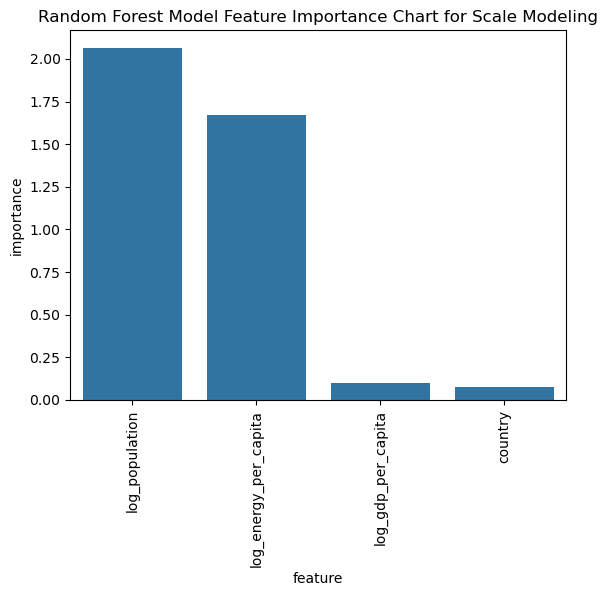

In [54]:
perm_df.head()
sns.barplot(perm_df, x='feature', y='importance')
plt.title("Random Forest Model Feature Importance Chart for Scale Modeling")
plt.xticks(rotation=90)
plt.show()

Permutation Importance for Random Forest Model shows similar results to Ridge Regression Model with Population being the dominating driver for co2 emissions.

We will remove the population signal, model for co2 per capita in the next set of models and look at the insights from those models.

## 5.7 Test Models for Second Feature Set (Population_Signal_Removed)<a id='All_Models'></a>

In [55]:
#Ordinary Least Squares Unscaled Model
#fit the ols model
ols_model2 = smf.ols('log_co2_per_capita ~ log_gdp_per_capita + log_energy_per_capita + C(country)', data = train2).fit()
#print ols model summary
print(ols_model2.summary())

                            OLS Regression Results                            
Dep. Variable:     log_co2_per_capita   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1927.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:32:28   Log-Likelihood:                 970.46
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3879   BIC:                            -579.0
Df Model:                         163                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [56]:
#predict model and get rmse score
test2['ols_pred'] = ols_model2.predict(test2)
rmse = np.sqrt(mean_squared_error(test2[target2],test2['ols_pred']))
print(rmse)

0.2626526490737511


In [66]:
#Ordinary Least Squares Scaled Model
#fit the ols model
ols_model2_scaled = smf.ols('log_co2_per_capita ~ log_gdp_per_capita + log_energy_per_capita + C(country)', data = train2_scaled).fit()
#print ols model summary
print(ols_model2_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:     log_co2_per_capita   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1927.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:20:09   Log-Likelihood:                 970.46
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3879   BIC:                            -579.0
Df Model:                         163                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [67]:
#predict ols scaled model and get rmse score
test2_scaled['ols_pred_scaled'] = ols_model2_scaled.predict(test2_scaled)
rmse = np.sqrt(mean_squared_error(test2_scaled[target2],test2_scaled['ols_pred_scaled']))
print(rmse)

0.26265264907375796


In [57]:
#Ridge Regression Scaled Model
#preprocess columns using scaler and then onehotencoder for categorical features
preprocessor2 = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features2),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features2),
    ]
)

#pipeline for ridge regression model
pipeline_ridge2 = Pipeline([
        ('preprocessor2', preprocessor2),
        ('model2', Ridge())
])

#crossvalidation and grid search
tscv2 = TimeSeriesSplit(n_splits=5)
param_grid_ridge2 = {'model2__alpha': [0.1, 1, 10, 50, 100] }
grid_ridge2 = GridSearchCV(pipeline_ridge2, param_grid_ridge2, cv=tscv2, scoring = 'neg_mean_squared_error', n_jobs=-1)

#Fit Ridge Model and get best params
grid_ridge2.fit(X_train2, y_train2)
print(grid_ridge2.best_params_)

{'model2__alpha': 10}


In [58]:
#predict model and get rmse score
ridge_pred2 = grid_ridge2.predict(X_test2)
rmse = np.sqrt(mean_squared_error(test2[target2], ridge_pred2))
print(rmse)

0.23111326800535706


In [103]:
# 1. Access the fitted preprocessor from the best grid search model
fitted_preprocessor = grid_ridge2.best_estimator_.named_steps['preprocessor2']

# 2. Get the new feature names
feature_names = fitted_preprocessor.get_feature_names_out()
print(feature_names)

['num__log_gdp_per_capita' 'num__log_energy_per_capita'
 'cat__country_Afghanistan' 'cat__country_Albania' 'cat__country_Algeria'
 'cat__country_Angola' 'cat__country_Argentina' 'cat__country_Armenia'
 'cat__country_Australia' 'cat__country_Austria' 'cat__country_Azerbaijan'
 'cat__country_Bahrain' 'cat__country_Bangladesh' 'cat__country_Barbados'
 'cat__country_Belarus' 'cat__country_Belgium' 'cat__country_Benin'
 'cat__country_Bolivia' 'cat__country_Bosnia and Herzegovina'
 'cat__country_Botswana' 'cat__country_Brazil' 'cat__country_Bulgaria'
 'cat__country_Burkina Faso' 'cat__country_Burundi'
 'cat__country_Cambodia' 'cat__country_Cameroon' 'cat__country_Canada'
 'cat__country_Cape Verde' 'cat__country_Central African Republic'
 'cat__country_Chad' 'cat__country_Chile' 'cat__country_China'
 'cat__country_Colombia' 'cat__country_Comoros' 'cat__country_Congo'
 'cat__country_Costa Rica' "cat__country_Cote d'Ivoire"
 'cat__country_Croatia' 'cat__country_Cuba' 'cat__country_Cyprus'
 'cat

Text(0.5, 1.0, 'Ridge Regression Feature Importance')

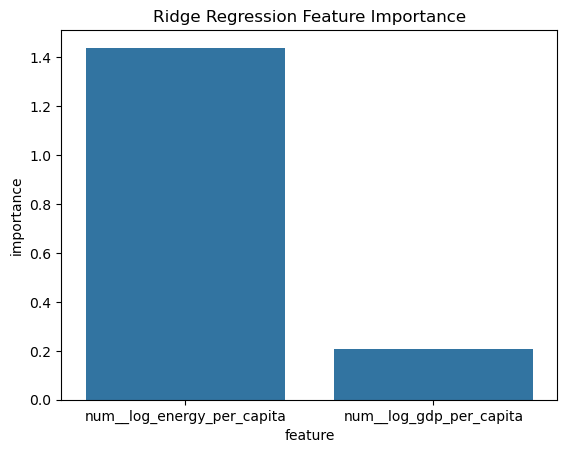

In [115]:
#assessing feature importance with ridge regression model
ridge_model = grid_ridge2.best_estimator_
coef = ridge_model.named_steps['model2'].coef_
features = ridge_model.named_steps['preprocessor2'].get_feature_names_out()
ridge_feature_imp = pd.DataFrame({'feature': features, 'coefficient': coef, 'importance':np.abs(coef)}).sort_values(by='importance',ascending=False)
ridge_feature_imp_core = ridge_feature_imp[ridge_feature_imp['feature'].isin(['num__log_energy_per_capita','num__log_gdp_per_capita'])]
ridge_feature_imp_core
_=sns.barplot(ridge_feature_imp_core, x='feature', y='importance')
plt.title("Ridge Regression Feature Importance")

We can see that energy intensity drives co2 emissions much more than economic output.

In [59]:
#Random Forest Scaled Model
#pipeline + grid search
pipeline2 = Pipeline([('preprocessor2', preprocessor2), ('model2', RandomForestRegressor(random_state=42))])
param_grid2= {
            'model2__n_estimators': [100,200],
            'model2__max_depth': [5,10],
            'model2__min_samples_split': [2,5],
            'model2__min_samples_leaf': [1,2]
            }

grid_rf2 = GridSearchCV(pipeline2, param_grid2, cv = tscv2, scoring ='neg_root_mean_squared_error', n_jobs=-1)

#fit model and get best params
grid_rf2.fit(X_train2, y_train2)
print(grid_rf2.best_params_)

{'model2__max_depth': 10, 'model2__min_samples_leaf': 2, 'model2__min_samples_split': 2, 'model2__n_estimators': 200}


In [60]:
#predict model and get rmse score
rf_pred2 = grid_rf2.predict(X_test2)
rmse = np.sqrt(mean_squared_error(test2[target2], rf_pred2))
print(rmse)

0.2468433996531561


In [83]:
#Random Forest Permutation Test for Feature Importance
perm_importance2 = permutation_importance(
   grid_rf2, X_test2, y_test2, n_repeats=10, random_state=42
)

perm_df2 = pd.DataFrame({
    'feature': X_test2.columns,
    'importance': perm_importance2.importances_mean
}).sort_values(by='importance', ascending=False)

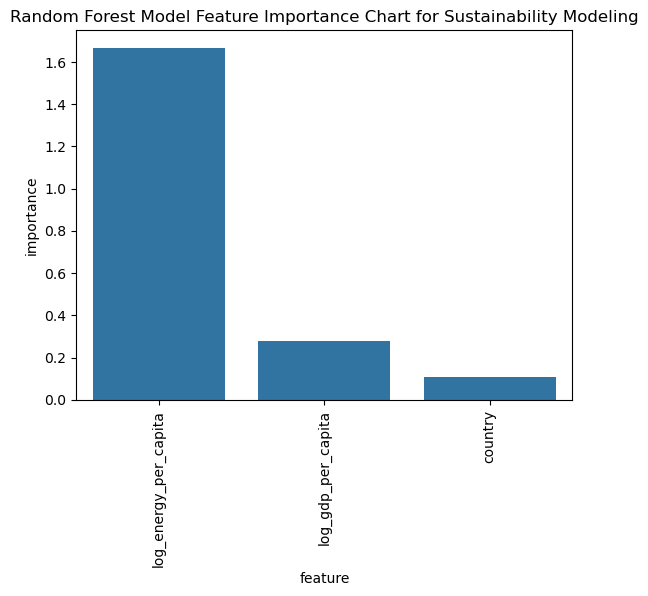

In [84]:
perm_df2.head()
sns.barplot(perm_df2, x='feature', y='importance')
plt.title("Random Forest Model Feature Importance Chart for Sustainability Modeling")
plt.xticks(rotation=90)
plt.show()

Here, we clearly see that CO2 per capita is driven by energy consumption per person followed by moderate impact of gdp per capita and country effect is small meaning differences across countries are largely explained by energy consumption and economic structure.

## 5.8 Final Models Selection<a id='5.8_Final_Model_Selection'></a>

It looks like both sets of models are telling us different stories. First set is for predicting global CO2 emissions with the importance of population signal and hence would be pointing to the dominant countries impacting overall CO2 emissions the most. Second one helps us understand how carbon intensive each country per person is and hence points to efficiency instead of scale (population dominance).  We will be looking at the best performing model from both sets and then finalize the model to proceed with.

### Model Performance Comparison

In [68]:
#Models Evaluation and Comparison for 1ST Feature Set (Scale Impact)
# define evaluation function

def evaluate(y_test, y_pred, model_name):
    print(f"{model_name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("-"*30)

evaluate(y_test, test['ols_pred'], "OLS Fixed Effect Model")
evaluate(y_test, test_scaled['ols_pred_scaled'], "OLS Fixed Effect Scaled Model")
evaluate(y_test, ridge_pred, "Ridge Regression Scaled Model")    
evaluate(y_test, rf_pred, "Random Forest Scaled Model")    

OLS Fixed Effect Model
RMSE: 0.2625980595499516
MAE: 0.20054266737421098
R2: 0.9850241940436423
------------------------------
OLS Fixed Effect Scaled Model
RMSE: 0.2625980595499519
MAE: 0.20054266737420962
R2: 0.9850241940436423
------------------------------
Ridge Regression Scaled Model
RMSE: 0.2311889197366216
MAE: 0.16703083261718243
R2: 0.9883924326983099
------------------------------
Random Forest Scaled Model
RMSE: 0.3007507242659256
MAE: 0.20493004991464586
R2: 0.9803564243908519
------------------------------


In [70]:
#Models Evaluation and Comparison for 2nd Feature Set (Sustainability Impact)

evaluate(y_test2, test2['ols_pred'], "OLS Fixed Effect Model")
evaluate(test2_scaled[target2], test2_scaled['ols_pred_scaled'], "OLS Fixed Effect Scaled Model")
evaluate(y_test2, ridge_pred2, "Ridge Regression Scaled Model")    
evaluate(y_test2, rf_pred2, "Random Forest Scaled Model")    

OLS Fixed Effect Model
RMSE: 0.2626526490737511
MAE: 0.20060131487115176
R2: 0.969232337350566
------------------------------
OLS Fixed Effect Scaled Model
RMSE: 0.26265264907375796
MAE: 0.20060131487115723
R2: 0.9692323373505644
------------------------------
Ridge Regression Scaled Model
RMSE: 0.23111326800535706
MAE: 0.16670256791846907
R2: 0.9761778644413016
------------------------------
Random Forest Scaled Model
RMSE: 0.2468433996531561
MAE: 0.18167904951138036
R2: 0.9728247234393858
------------------------------


We evaluated 2 Linear Regression Models - OLS, Ridge & then Random Forest Model for two sets of features (one with total co2 emissions as target variable and another with co2_per_capita. RMSE, MAE and R2 values are best for Ridge Regression Model for both feature sets. Ridge Regression Model using co2_per_capita as our target variable will be our strategy and model of choice since we are more interested in understanding the impact of energy and gdp (efficiency and sustainability) compared to population (scale impact).

## 5.9 Save best model object from pipeline<a id='5.9_Save_best_model_object_from_pipeline'></a>

In [43]:
#best model object
best_model = grid_ridge2.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train2.columns]
best_model.build_datetime = datetime.datetime.now()

In [44]:
print(best_model)

Pipeline(steps=[('preprocessor2',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_gdp_per_capita',
                                                   'log_energy_per_capita']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country'])])),
                ('model2', Ridge(alpha=10))])


In [45]:
# save the model
modelpath = '../models'
save_file(best_model, 'co2_per_capita_insights_model.pkl', modelpath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../models\co2_per_capita_insights_model.pkl"


## 5.10 Plastics Connection<a id='5.10_Plastics_Connection'></a>

While we modeled country level carbon dioxide emissions using energy, economic and demographic indicators, we know based on our exploratory data analysis that global plastics production has increased a lot over the past several decades along side global gdp, energy per capita and population.

Let's plot the global co2 emissions and plastics production growth trend over the past 3 decades together to see how closely the trends follow each other using the globalized plastics co2 normalized dataset.

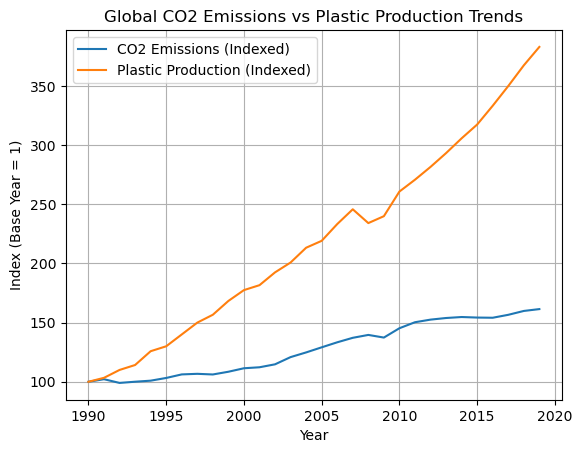

In [79]:
# Plotting Plastics Trend alongside CO2 emissions trend for the normalized dataset
global_co2_plastics_norm = global_co2_plastics_norm.sort_values('year')
plt.plot(global_co2_plastics_norm['year'], global_co2_plastics_norm['total_co2_mt'], label='CO2 Emissions (Indexed)')
plt.plot(global_co2_plastics_norm['year'], global_co2_plastics_norm['Total_Plastic_Production_Million_Tonnes'], label='Plastic Production (Indexed)')
plt.title('Global CO2 Emissions vs. Plastic Production Trend Over Past Decades')
plt.xlabel('Year')
plt.ylabel('Index (Start Year (1990) = 1)')
plt.legend()
plt.grid()
plt.show()

We can see from the indexed global co2 and plastics production trend chart below that plastics production has increased over 280% in the last 3 decades while global co2 emissions have increased by ~60%. While both show a growing trend, slower co2 emissions growth seems to be primarily due to cleaner technology and energy efficient/green projects and processes. However, the rapidly growing plastics production still requires energy intensive materials and processes which continue to contribute towards co2 emssions and hence global warming.

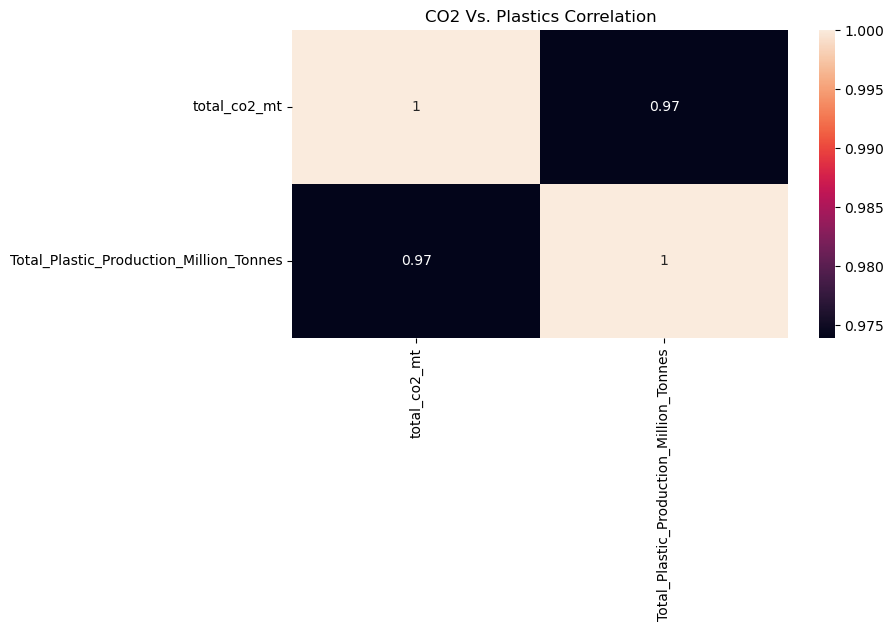

In [146]:
##correlation between plastic production and co2 emissions
plt.figure(figsize=(8,4))
sns.heatmap(global_co2_plastics_data[['total_co2_mt','Total_Plastic_Production_Million_Tonnes']].corr(), annot=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("CO2 Vs. Plastics Correlation")
plt.show()

The strong positive correlation between Global CO2 Emissions and Plastics Production further supports their co movement over the past several decades.

This further strengthens our narrative of Plastics Production being a macro driver of co2 emissions and hence global warming.

## 5.11 Conclusion<a id='5.10_Conclusion'></a>

We set out to predict the impact of national economic activity, energy usage and demographic indicators within the context of increasingly plastic intensive global supply chains over the past many decades on global warming using carbon dioxide emission levels as our key indicator.

When looking at total co2 emissions at country level, population size seems to play a major role in predicting co2 emissions.

However, when looking at co2 emissions per capita, with the population signal removed, energy per capita (energy intensity) becomes the dominant driver of co2 emissions with gdp per capita having a much smaller impact on emissions.

These results can be confirmed across both linear and non linear models that we used for this study.

Plastics Production also seems to be a macro driver of co2 emissions because of its energy intensive nature.

## 5.12 Actionable Insights<a id='5.12_Actionable_Insights'></a>

1. Since energy per capita (energy intensity) emerged as the major driver of co2 emissions, one of the key recommendations would be to track energy per capita at country level, focusing on energy intensive industries and processes and take appropriate actions to reduce the energy demand or switch to cleaner energy sources.

2. For developing countries like India, China with huge population size, total co2 emissions should be tracked closely alongside energy per capita and greener energy projects should be incentivized and adopted aggressively.

2. Since Plastic Production seems to be growing rapidly and contributing towards global warming, recycling projects and greener plastic alternatives should be invested in and given a priority.

3. It would also be helpful to track plastics data for the entire life cycle at country level every year going forward to build a better predictive model for co2 emissions based on plastics as one of the key features.

## 5.13 Summary<a id='4.13_Summary'></a>

1. We started by loading the train/test sets for two different feature/target set strategies created during Preprocessing and Training Data step. 

2. Following are the two modeling strategies that were implemented for capturing different perspectives.

* For the first model, log_co2 (total co2 emissions) was our target and features used for modeling were log_population, log_energy_per_capita & log_gdp_per_capita 
This model had a good predictive performance, however population signal dominated all other features as countries like India, China etc. with huge population tend to contribute significantly towards total co2 emissions. So, we had a scale effect with this strategy and it was not very useful for interpreting efficiency.

* For the second model, log_co2_per_capita was our target and log_energy_per_capita and log_gdp_per_capita were our primary features.
This model had higher interpretability as it captured co2 emissions intensity rather than scale and it aligns better with sustainability and decoupling analysis.

3. The following models were implemented for both these strategies

* Ordinary Least Squares Model (Scaled and Unscaled) with countries as categorical variables
* Scaled Ridge Regression Model with Hyperparameter Tuning, Crossvalidation and feature importance assessment.
* Random Forest Model with Hyperparameter Tuning, Crossvalidation and permutation importance for feature importance assessment.

5. RMSE, MAE and R2 metrics were used for model evaluation.

6. We observed that total co2 models achieved higher R2 due to population dominance whereas co2 per capita models showed slightly lower R2 but greater interpretability. Both Ridge Regression and Random Forest model confirmed Energy per capita as the strongest predictor, GDP per capita as secondary with minimal reliance on country-specific effects for the co2_per_capita model.

7. Modeling results for these strategies showed that while total co2 emissions are largely driven by population size, co2 per capita is primarily determined by energy consumption behavior. This points to the importance of energy efficiency in reducing environmental impact.

8. Hence, we decided to model for co2_per_capita using Ridge Regression model since it performed the best.

9. Our main insight from this analysis is that in order to reduce co2 emissions and global warming, focus on energy efficiency and cleaner energy sources is more critical compared to economic growth and population factors especially for plastic intensive supply chains globally.